Saved: RF_ResNet18_Test.png


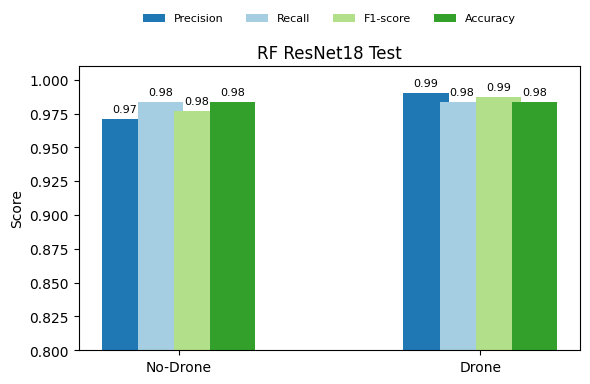

Saved: Audio_LogMel_CNN_Test.png


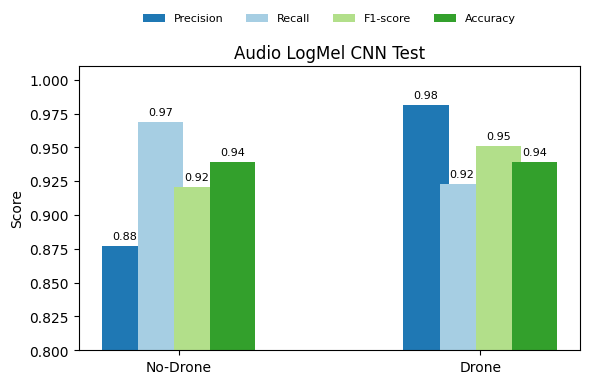

Saved: Video_MobileNet_Test.png


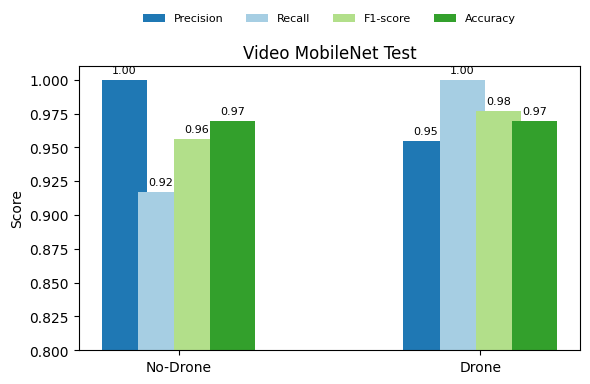

Saved: Audio_VGG_MFCC_Test.png


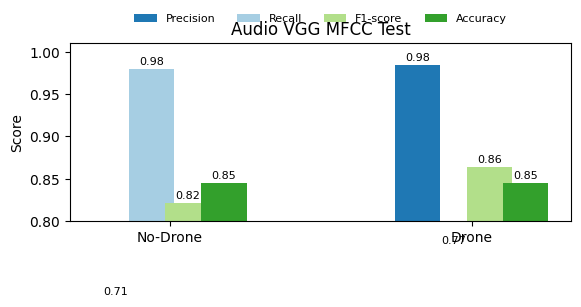

Saved: RF_3D_CNN_Test.png


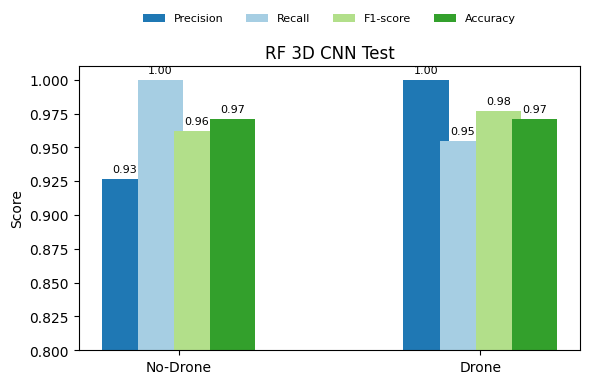

Saved: Video_3D_CNN_Test.png


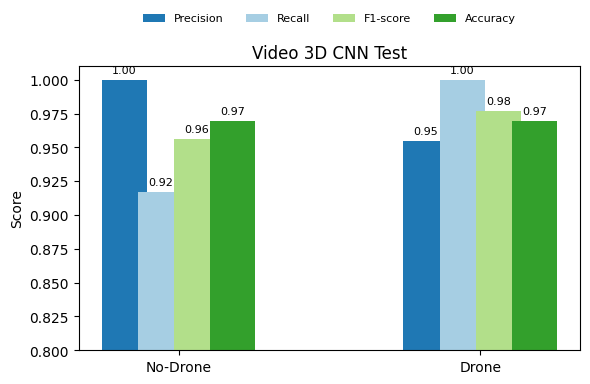

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# Function: Compact Per-Class Plot
# ==========================
def plot_per_class_from_table(model_name, no_drone, drone, accuracy):

    class_names = ["No-Drone", "Drone"]

    precision = [no_drone[0], drone[0]]
    recall    = [no_drone[1], drone[1]]
    f1_score  = [no_drone[2], drone[2]]
    acc       = [accuracy, accuracy]

    paired_colors = ['#1f78b4', '#a6cee3', '#b2df8a', '#33a02c']

    x = np.arange(len(class_names))
    width = 0.15

    plt.figure(figsize=(6, 4))

    bars1 = plt.bar(x - 1.2*width, precision, width, label="Precision", color=paired_colors[0])
    bars2 = plt.bar(x - 0.4*width, recall, width, label="Recall", color=paired_colors[1])
    bars3 = plt.bar(x + 0.4*width, f1_score, width, label="F1-score", color=paired_colors[2])
    bars4 = plt.bar(x + 1.2*width, acc, width, label="Accuracy", color=paired_colors[3])

    plt.xticks(x, class_names)
    plt.ylim(0.8, 1.01)
    plt.ylabel("Score")
    plt.title(model_name)

    # Legend ثابت فوق
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.22),
        ncol=4,
        fontsize=8,
        frameon=False
    )

    # Add values above bars
    def add_labels(bars):
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.005,
                f"{h:.2f}",
                ha="center",
                fontsize=8
            )

    for bars in [bars1, bars2, bars3, bars4]:
        add_labels(bars)

    plt.tight_layout()

    filename = model_name.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_") + ".png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print("Saved:", filename)

    plt.show()


# ==========================
# All Uni-Model Results
# ==========================
models_results = {
    "RF ResNet18 Test": {
        "no_drone": [0.9712, 0.9833, 0.9772],
        "drone":    [0.9904, 0.9833, 0.9869],
        "accuracy": 0.9833
    },

    "Audio LogMel CNN Test": {
        "no_drone": [0.8774, 0.9688, 0.9208],
        "drone":    [0.9810, 0.9226, 0.9509],
        "accuracy": 0.9394
    },

    "Video MobileNet Test": {
        "no_drone": [1.0000, 0.9167, 0.9565],
        "drone":    [0.9545, 1.0000, 0.9767],
        "accuracy": 0.9697
    },

    "Audio VGG MFCC Test": {
        "no_drone": [0.7078, 0.9792, 0.8217],
        "drone":    [0.9848, 0.7690, 0.8636],
        "accuracy": 0.8455
    },

    "RF 3D CNN Test": {
        "no_drone": [0.9266, 1.0000, 0.9619],
        "drone":    [1.0000, 0.9548, 0.9769],
        "accuracy": 0.9712
    },

    "Video 3D CNN Test": {
        "no_drone": [1.0000, 0.9167, 0.9565],
        "drone":    [0.9545, 1.0000, 0.9767],
        "accuracy": 0.9697
    }
}


# ==========================
# Generate and save all plots
# ==========================
for model_name, values in models_results.items():
    plot_per_class_from_table(
        model_name=model_name,
        no_drone=values["no_drone"],
        drone=values["drone"],
        accuracy=values["accuracy"]
    )

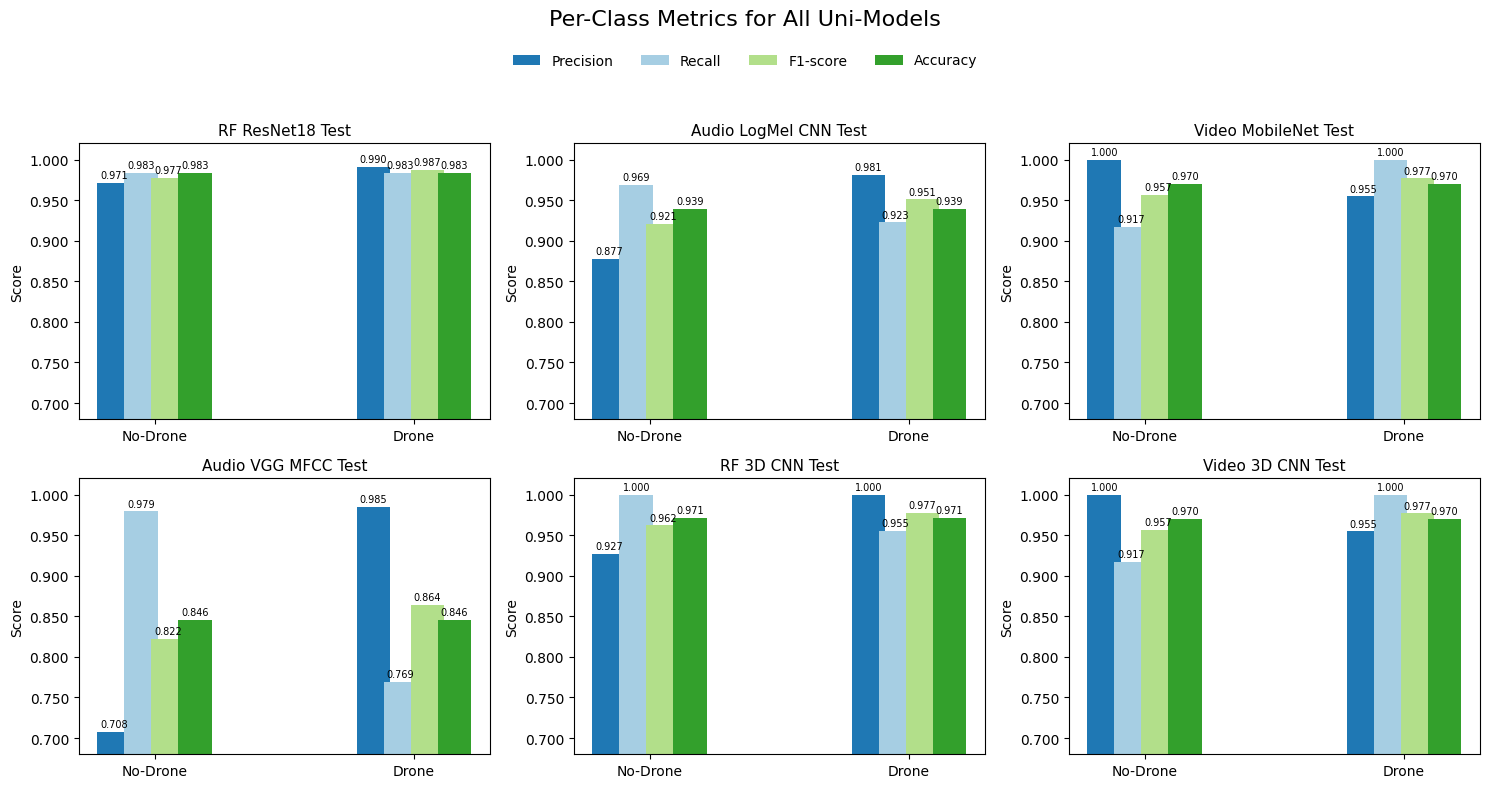

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter  # ✅ إضافة

# ==========================
# All Uni-Model Results
# ==========================
models_results = {
    "RF ResNet18 Test": {
        "no_drone": [0.9712, 0.9833, 0.9772],
        "drone":    [0.9904, 0.9833, 0.9869],
        "accuracy": 0.9833
    },

    "Audio LogMel CNN Test": {
        "no_drone": [0.8774, 0.9688, 0.9208],
        "drone":    [0.9810, 0.9226, 0.9509],
        "accuracy": 0.9394
    },

    "Video MobileNet Test": {
        "no_drone": [1.0000, 0.9167, 0.9565],
        "drone":    [0.9545, 1.0000, 0.9767],
        "accuracy": 0.9697
    },

    "Audio VGG MFCC Test": {
        "no_drone": [0.7078, 0.9792, 0.8217],
        "drone":    [0.9848, 0.7690, 0.8636],
        "accuracy": 0.8455
    },

    "RF 3D CNN Test": {
        "no_drone": [0.9266, 1.0000, 0.9619],
        "drone":    [1.0000, 0.9548, 0.9769],
        "accuracy": 0.9712
    },

    "Video 3D CNN Test": {
        "no_drone": [1.0000, 0.9167, 0.9565],
        "drone":    [0.9545, 1.0000, 0.9767],
        "accuracy": 0.9697
    }
}

# ==========================
# Plot all models in one figure
# ==========================
def plot_all_per_class_one_figure(models_results):

    class_names = ["No-Drone", "Drone"]
    colors = ['#1f78b4', '#a6cee3', '#b2df8a', '#33a02c']

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    width = 0.13
    gap_factor = 0.8

    for ax, (model_name, values) in zip(axes, models_results.items()):

        no_drone = values["no_drone"]
        drone = values["drone"]
        accuracy = values["accuracy"]

        precision = [no_drone[0], drone[0]]
        recall    = [no_drone[1], drone[1]]
        f1_score  = [no_drone[2], drone[2]]
        acc       = [accuracy, accuracy]

        x = np.arange(len(class_names))

        bars1 = ax.bar(x - 1.5*width*gap_factor, precision, width, label="Precision", color=colors[0])
        bars2 = ax.bar(x - 0.5*width*gap_factor, recall, width, label="Recall", color=colors[1])
        bars3 = ax.bar(x + 0.5*width*gap_factor, f1_score, width, label="F1-score", color=colors[2])
        bars4 = ax.bar(x + 1.5*width*gap_factor, acc, width, label="Accuracy", color=colors[3])

        ax.set_xticks(x)
        ax.set_xticklabels(class_names)
        ax.set_ylim(0.68, 1.02)
        ax.set_title(model_name, fontsize=11)
        ax.set_ylabel("Score")

        # ✅ تنسيق Y-axis لثلاث خانات عشرية
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

        # الأرقام فوق البارز (خليتها 3 decimal بعد 👍)
        for bars in [bars1, bars2, bars3, bars4]:
            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    h + 0.006,
                    f"{h:.3f}",
                    ha="center",
                    fontsize=7
                )

    handles, labels = axes[0].get_legend_handles_labels()

    fig.suptitle(
        "Per-Class Metrics for All Uni-Models",
        fontsize=16,
        y=0.98
    )

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=4,
        fontsize=10,
        frameon=False,
        bbox_to_anchor=(0.5, 0.94)
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])

    plt.savefig("All_Uni_Models_Per_Class.png", dpi=300, bbox_inches="tight")
    plt.show()
# Run
plot_all_per_class_one_figure(models_results)